# The focal node

The ancestral state is evaluated at one node of the tree, so that node has to be chosen. {class}`~ancestree.focal.FocalNode` names it, and every mode reports at the same one. It defaults to the ingroup's most recent common ancestor, whose state is the ancestral allele of the ingroup, the node an ingroup polymorphism is a statement about. Moving it deeper asks a different question: the ingroup MRCA and the panel's deepest ancestor are separated by the ingroup-to-outgroup divergence, and a mutation on that branch changes the state at one end but not the other, so the two readings are distinct quantities, whether an allele is derived within the ingroup or relative to the outgroups.


## Node placement

Any tree serves to illustrate the choice. The one below is a fixed-tree outgroup ladder, drawn with the reporting position marked ({class}`~ancestree.plotting.FocalTreePlot`): the ingroup collapses to a single tip, and three outgroups join the ingroup lineage in order of decreasing relatedness. The three panels place the {class}`~ancestree.focal.FocalNode` at the ingroup MRCA, halfway up to the panel root, and at the panel root.


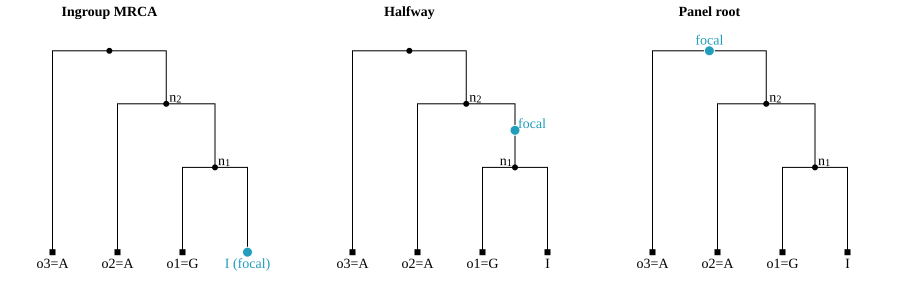

In [1]:
import ancestree as anc
from ancestree.focal import FocalNode
from ancestree.plotting import FocalTreePlot
from ancestree.sites import Site
from IPython.display import SVG

ingroup = [f"i{k}" for k in range(6)]
ladder = anc.OutgroupLadderTree(ingroup, ["o1", "o2", "o3"])
ladder.set_params([0.004, 0.008, 0.006, 0.014, 0.020])

# The ingroup is fixed for G; the two more distant outgroups carry A.
site = Site(chrom="1", pos=1, alleles=("A", "G"),
            tip_alleles={**{s: "G" for s in ingroup},
                         "o1": "G", "o2": "A", "o3": "A"})

positions = [("Ingroup MRCA", None),
             ("Halfway", FocalNode("ingroup_mrca", fraction=0.5)),
             ("Panel root", FocalNode("panel_root"))]
SVG(FocalTreePlot.draw_svg_row(ladder, positions, site=site, size=(300, 260)))


## Specifying the focal node

Every inference mode takes the same `focal` argument. Two anchors are available, each denoting a node rather than a stored rooting: `"ingroup_mrca"`, the default, is the most recent common ancestor of the ingroup, and `"panel_root"` that of the whole panel. The substitution models are time-reversible, so the tree may be re-rooted at any node or at any point along a branch. The position between the anchors is therefore continuous, and may be given in any one of three units:

| unit | definition | comparable across |
|---|---|---|
| `fraction` | position along the anchor-to-root path, in `[0, 1]` | every mode and dataset, being scale-free |
| `coalescences` | number of coalescences above the anchor | trees of equal shape |
| `depth` | absolute distance from the sample plane, in the tree's own branch units | every local tree of one dataset |

Only `depth` denotes one point across trees of differing height, which is what makes a divergence question comparable when the number of outgroups, and with it the panel root, varies. Each view below reports the source-tree node its root sits above and the distance `tau` above it, in the tree's own branch units.

In [2]:
tree = ladder  # an OutgroupLadderTree, or a RerootedTree view of any Tree
for spec in (FocalNode(),
             FocalNode("ingroup_mrca", coalescences=1),
             FocalNode("ingroup_mrca", fraction=0.25),
             FocalNode("ingroup_mrca", depth=0.006),
             FocalNode("panel_root")):
    offset = "".join(
        f", {name}={value}" for name, value in
        (("fraction", spec.fraction), ("coalescences", spec.coalescences),
         ("depth", spec.depth)) if value is not None
    )
    view = tree.at_focal(spec)
    anchor, tau = view.placement
    print(f"{spec.anchor + offset:38s} -> split above node {anchor} at tau={tau:.3g}")

ingroup_mrca                           -> split above node 0 at tau=0
ingroup_mrca, coalescences=1           -> split above node 4 at tau=0
ingroup_mrca, fraction=0.25            -> split above node 4 at tau=0.00025
ingroup_mrca, depth=0.006              -> split above node 5 at tau=0.004
panel_root                             -> split above node 3 at tau=0.015


## Varying the focal node

The position matters. {class}`~ancestree.plotting.FocalSweep` evaluates the posterior along the path from the ingroup MRCA to the panel root, here at the same site as above, where every ingroup sample carries `G` and only the outgroups, two of which carry `A`, can resolve the ancestral allele.


In [3]:
%config InlineBackend.figure_formats = ["svg"]


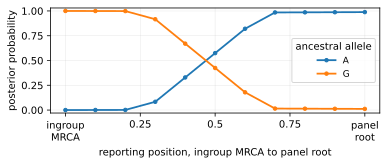

In [4]:
import matplotlib.pyplot as plt

from ancestree.plotting import FocalSweep

fig, ax = plt.subplots(figsize=(5.4, 2.4))
FocalSweep(ladder, site, anc.JC69()).draw(ax)
fig.tight_layout()


In [5]:
ends = FocalSweep(ladder, site, anc.JC69(), fractions=(0.0, 1.0)).posteriors()
assert ends[0, anc.STATES.index("G")] > 0.999
assert ends[1, anc.STATES.index("A")] > 0.9


At the ingroup MRCA the posterior is `G` with probability one: the state there is the observed allele. Moving the position toward the panel root hands the question to the outgroups, and at the root almost all mass falls on `A`. A site monomorphic within the ingroup therefore calls for a deeper reporting position than a polymorphic one.


## Ingroup MRCA versus panel root

ARG and local-tree mode treat every tip symmetrically: the kernel weights no sample differently for being an outgroup, and outgroups contribute through the topology and branch lengths like any other tip. The ingroup and outgroup labels determine the reporting node and the panel. When both are given, samples belonging to neither are excluded from the inference. When only outgroups are given, the other haplotypes of an outgroup individual are excluded as well. {paramref}`ingroup_samples <ancestree.inference.ARGBasedInference.ingroup_samples>` defaults to every sample whose individual is not named as an outgroup, so when neither is given the ingroup is the whole panel and the two anchors coincide at the panel root. Below, the same ARG is run at each anchor.

:::{note}
Under incomplete lineage sorting the ingroup is frequently not monophyletic, so its most recent common ancestor subtends outgroup tips as well. The reading then degrades continuously toward the panel root rather than failing, and the affected trees are counted in the {meth}`provenance <ancestree.inference.Inference.provenance>` as `n_trees_ingroup_non_monophyletic`.
:::


In [6]:
import tskit

ts = tskit.load("quickstart.trees")
outgroup = ["o0", "o1"]

res = {}
for anchor in ("ingroup_mrca", "panel_root"):
    inf = anc.Inference.from_arg(
        ts, anc.JC69(), mu=5e-8, focal=anchor,
        ingroup_samples=ingroup, outgroup_samples=outgroup,
    )
    res[anchor] = list(inf.infer())

INFO:ancestree.ARGBasedInference: Inferring the ancestral allele at 224 sites over 29 local trees from the ARG
INFO:ancestree.ARGBasedInference: Using 6 ingroup sample(s): i0, i1, i2, i3, i4, i5
INFO:ancestree.ARGBasedInference: Using 2 outgroup sample(s): o0, o1
ARGBasedInference: 100%|██████████| 29/29 [00:00<00:00, 1822.63 trees/s]
INFO:ancestree.ARGBasedInference: Focal node: reported at the ingroup_mrca; 4 tree(s) where the ingroup is not monophyletic, so its MRCA subtends outgroup tips
INFO:ancestree.ARGBasedInference: Inferring the ancestral allele at 224 sites over 29 local trees from the ARG
INFO:ancestree.ARGBasedInference: Using 6 ingroup sample(s): i0, i1, i2, i3, i4, i5
INFO:ancestree.ARGBasedInference: Using 2 outgroup sample(s): o0, o1
ARGBasedInference: 100%|██████████| 29/29 [00:00<00:00, 1171.71 trees/s]


Below, the recovery of the ancestral allele is compared between the two reporting nodes, with the sites split into those polymorphic within the ingroup and those the ingroup has fixed, for the ancestral or for the derived allele. At a fixed site the state at the ingroup MRCA is the observed ingroup allele itself, so the ancestral allele is taken to be the state at the panel root, the node at which {class}`~ancestree.posterior.Grade` reads the truth through its `focal` argument.


In [7]:
# Sites polymorphic within the ingroup, and their complement.
keep = anc.PolymorphicSiteFilter(samples=ingroup)
fixed = ~keep

# The ancestral allele is the state at the panel root, and a fixed site is
# derived when the ingroup allele differs from it.
root = anc.Grade.truth_at_focal(ts, "panel_root")
derived = lambda site: site.tip_alleles[ingroup[0]] != root[site.pos]

classes = {
    "polymorphic": keep,
    "fixed ancestral": lambda site: fixed.accepts(site) and not derived(site),
    "fixed derived": lambda site: fixed.accepts(site) and derived(site),
}

# Mean Brier score per reporting node and site class, lower is better.
brier = {anchor: {name: anc.Grade(res[anchor], root, filter=f).brier
                  for name, f in classes.items()} for anchor in res}

print(f"{'Brier score at':<16}" + "".join(f"{name:>18}" for name in classes))
for anchor, row in brier.items():
    print(f"{anchor:<16}" + "".join(f"{row[name]:>18.3f}" for name in classes))

Brier score at         polymorphic   fixed ancestral     fixed derived
ingroup_mrca                 0.031             0.000             2.000
panel_root                   0.031             0.190             0.772


In [8]:
assert brier["ingroup_mrca"]["fixed ancestral"] < 0.01 and brier["ingroup_mrca"]["fixed derived"] > 1.9
assert brier["ingroup_mrca"]["fixed derived"] > brier["panel_root"]["fixed derived"] > 0.5 > brier["panel_root"]["fixed ancestral"]
assert abs(brier["ingroup_mrca"]["polymorphic"] - brier["panel_root"]["polymorphic"]) < 0.05

The polymorphic sites are unaffected by the choice of node in this example, although more distant outgroups may alter this. The fixed-derived sites cannot be recovered at the ingroup MRCA, since their mutation lies above that node and the state there is the derived allele itself. At the panel root they can be recovered in principle, yet with a single outgroup lineage only the branch lengths tell the ingroup stem from the outgroup stem as the site of the mutation. Resolving them requires a more distant outgroup.
